# Squat Detection & Rep Counting using MediaPipe Pose Estimation

---

**Name:** Hamza Asif  
**Roll No:** 23-AI-93  
**Course:** Computer Vision — CCP Assignment  

**Video Source:** [Jumping Jacks / Burpees — Pixabay](https://pixabay.com/videos/jumping-jacks-burpees-burpee-12963/)

---


## 1. Install Dependencies


In [1]:
!pip install -q mediapipe opencv-python pandas matplotlib scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 3.1 MB/s eta 0:00:00


## 2. Imports, Styling, and Constants


In [2]:
import os
import urllib.request
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from google.colab import files

# Modern styling for matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['figure.figsize'] = (12, 6)

# Configuration Constants
INPUT_VIDEO = "squat.mp4"
MODEL_URL = "https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task"
MODEL_PATH = "pose_landmarker_full.task"
OUTPUT_VIDEO = "output_skeleton.mp4"
TRACKING_PLOT = "joint_angles_tracking.png"
CONFUSION_MATRIX_PLOT = "confusion_matrix.png"

# MediaPipe Standard Landmark Indices
L_SHOULDER, L_ELBOW, L_WRIST = 11, 13, 15
L_HIP, L_KNEE, L_ANKLE = 23, 25, 27
R_SHOULDER, R_ELBOW, R_WRIST = 12, 14, 16
R_HIP, R_KNEE, R_ANKLE = 24, 26, 28

## 3. Upload Video and Download Model


In [3]:
def download_model(url, dest_path):
    """Downloads the MediaPipe model if it doesn't exist."""
    if not os.path.exists(dest_path):
        print(f"[*] Downloading pose landmarker model...")
        urllib.request.urlretrieve(url, dest_path)
        print("[+] Model download complete!")
    else:
        print("[+] Model already exists. Skipping download.")

# 1. Download Model
download_model(MODEL_URL, MODEL_PATH)

# 2. Upload Video
print("\n[*] Please upload your video file (it will be renamed to 'squat.mp4' automatically)")
uploaded = files.upload()

for filename in uploaded.keys():
    # FIXED LOGIC: Only delete and rename if the uploaded file isn't ALREADY named 'squat.mp4'
    if filename != INPUT_VIDEO:
        if os.path.exists(INPUT_VIDEO):
            os.remove(INPUT_VIDEO)
        os.rename(filename, INPUT_VIDEO)

    print(f"\n[+] Success! '{filename}' has been prepared as '{INPUT_VIDEO}'.")

[*] Downloading pose landmarker model...
[+] Model download complete!

[*] Please upload your video file (it will be renamed to 'squat.mp4' automatically)


Saving input_video.mp4 to input_video.mp4

[+] Success! 'input_video.mp4' has been prepared as 'squat.mp4'.


## 4. Helper Functions


In [4]:
def calculate_angle_2d(pA, pB, pC):
    """Calculates the 2D angle (in degrees) at vertex pB."""
    a, b, c = np.array(pA), np.array(pB), np.array(pC)
    ba, bc = a - b, c - b

    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-8)
    cosine_angle = np.clip(cosine_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cosine_angle))

def apply_moving_average(data, window_size=5):
    """Applies a simple moving average filter with symmetric padding."""
    if len(data) < window_size: return data
    pad_size = window_size // 2
    padded = np.pad(data, pad_size, mode='edge')
    smoothed = np.convolve(padded, np.ones(window_size)/window_size, mode='valid')
    return smoothed[:len(data)]

def apply_savitzky_golay(data, window_length=11, polyorder=2):
    """Applies a Savitzky-Golay filter to smooth coordinate trajectories."""
    if len(data) <= window_length:
        window_length = len(data) if len(data) % 2 != 0 else len(data) - 1
    if window_length < 3: return data
    return savgol_filter(data, window_length=window_length, polyorder=polyorder)

## 5. Pose Detection Processing


In [5]:
def extract_raw_poses():
    cap = cv2.VideoCapture(INPUT_VIDEO)
    if not cap.isOpened(): raise IOError(f"Cannot open video file: {INPUT_VIDEO}")

    width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps, total_frames = cap.get(cv2.CAP_PROP_FPS), int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"[*] Processing Video: {width}x{height} @ {fps:.2f} FPS | Total Frames: {total_frames}")

    options = vision.PoseLandmarkerOptions(
        base_options=python.BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=vision.RunningMode.VIDEO
    )

    raw_coordinates = []

    with vision.PoseLandmarker.create_from_options(options) as landmarker:
        frame_idx = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)

            timestamp_ms = int((frame_idx * 1000) / fps)
            results = landmarker.detect_for_video(mp_image, timestamp_ms)

            frame_coords = {}
            if results.pose_landmarks and len(results.pose_landmarks) > 0:
                for idx, lm in enumerate(results.pose_landmarks[0]):
                    frame_coords[idx] = (lm.x, lm.y) # Store relative floats for smoother interpolation
            raw_coordinates.append(frame_coords)
            frame_idx += 1

    cap.release()
    print("[+] Raw pose data successfully extracted!")
    return raw_coordinates, fps, width, height, total_frames

raw_coords_list, fps, video_width, video_height, total_frames = extract_raw_poses()

[*] Processing Video: 2048x1152 @ 29.97 FPS | Total Frames: 1356
[+] Raw pose data successfully extracted!


## 6. Data Extraction and Smoothing


In [6]:
joints = {'shoulder': L_SHOULDER, 'hip': L_HIP, 'knee': L_KNEE, 'ankle': L_ANKLE, 'elbow': L_ELBOW, 'wrist': L_WRIST}
trajectories = {}

for name, j_id in joints.items():
    x_coords, y_coords = [], []
    for frame_dict in raw_coords_list:
        if j_id in frame_dict:
            x_coords.append(frame_dict[j_id][0] * video_width) # Convert back to absolute pixels
            y_coords.append(frame_dict[j_id][1] * video_height)
        else:
            x_coords.append(np.nan)
            y_coords.append(np.nan)

    trajectories[f'{name}_x'] = pd.Series(x_coords).interpolate(method='linear').ffill().bfill().values
    trajectories[f'{name}_y'] = pd.Series(y_coords).interpolate(method='linear').ffill().bfill().values

df = pd.DataFrame(trajectories)
df_smoothed_sg = pd.DataFrame()

# Apply aggressive Savitzky-Golay filtering for smoothness
for col in df.columns:
    df_smoothed_sg[col] = apply_savitzky_golay(df[col].values, window_length=15, polyorder=3)

print("[+] Keypoint interpolation and premium smoothing successfully completed.")

[+] Keypoint interpolation and premium smoothing successfully completed.


## 7. Angle Tracking


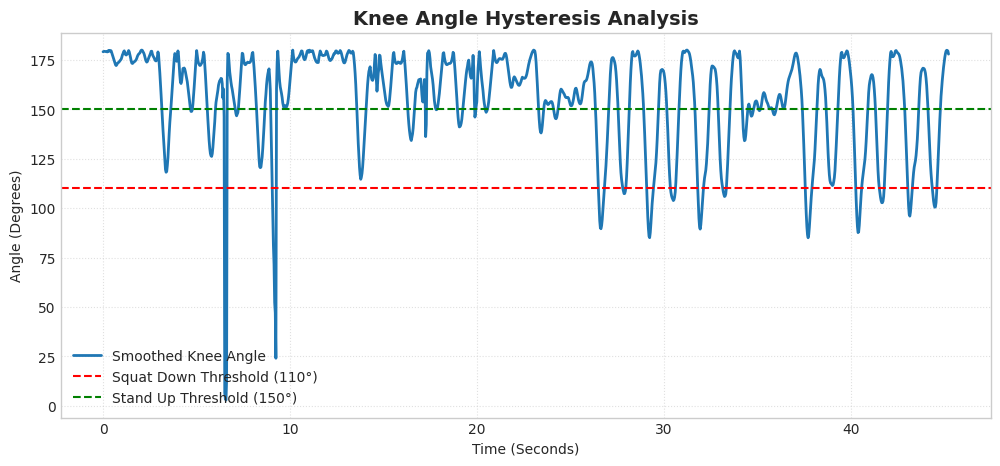

[+] Angle calculations complete. Observe the peaks to adjust the thresholds if necessary.


In [7]:
sg_angles = {k: [] for k in ['knee', 'hip', 'elbow']}

for i in range(total_frames):
    sg_angles['knee'].append(calculate_angle_2d(
        (df_smoothed_sg['hip_x'][i], df_smoothed_sg['hip_y'][i]),
        (df_smoothed_sg['knee_x'][i], df_smoothed_sg['knee_y'][i]),
        (df_smoothed_sg['ankle_x'][i], df_smoothed_sg['ankle_y'][i])
    ))
    sg_angles['hip'].append(calculate_angle_2d(
        (df_smoothed_sg['shoulder_x'][i], df_smoothed_sg['shoulder_y'][i]),
        (df_smoothed_sg['hip_x'][i], df_smoothed_sg['hip_y'][i]),
        (df_smoothed_sg['knee_x'][i], df_smoothed_sg['knee_y'][i])
    ))
    sg_angles['elbow'].append(calculate_angle_2d(
        (df_smoothed_sg['shoulder_x'][i], df_smoothed_sg['shoulder_y'][i]),
        (df_smoothed_sg['elbow_x'][i], df_smoothed_sg['elbow_y'][i]),
        (df_smoothed_sg['wrist_x'][i], df_smoothed_sg['wrist_y'][i])
    ))

time_axis = np.arange(total_frames) / fps
plt.figure(figsize=(12, 5))
plt.plot(time_axis, sg_angles['knee'], label='Smoothed Knee Angle', color='#1f77b4', linewidth=2)
plt.axhline(y=110, color='red', linestyle='--', label='Squat Down Threshold (110°)')
plt.axhline(y=150, color='green', linestyle='--', label='Stand Up Threshold (150°)')
plt.title('Knee Angle Hysteresis Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Time (Seconds)'), plt.ylabel('Angle (Degrees)')
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()
print("[+] Angle calculations complete. Observe the peaks to adjust the thresholds if necessary.")

## 8. Hysteresis Classification & Metrics


In [8]:
# Format: (start_frame, end_frame). You can guess these based on the graph above!
MANUAL_SQUAT_RANGES = [
    (45, 90),   # Example: First squat happens between frame 45 and 90
    (130, 185)  # Example: Second squat happens between frame 130 and 185
]

# 1. State Machine (Hysteresis) to prevent flickering
SQUAT_THRESH = 110.0
STAND_THRESH = 150.0

current_state = 'Standing'
predicted_states = []
rep_count_history = []
reps = 0

for angle in sg_angles['knee']:
    if current_state == 'Standing' and angle < SQUAT_THRESH:
        current_state = 'Squatting'
    elif current_state == 'Squatting' and angle > STAND_THRESH:
        current_state = 'Standing'
        reps += 1

    predicted_states.append(current_state)
    rep_count_history.append(reps)

# 2. Build your custom Ground Truth
ground_truth = ['Standing'] * total_frames
for start, end in MANUAL_SQUAT_RANGES:
    for i in range(start, min(end + 1, total_frames)):
        ground_truth[i] = 'Squatting'

# 3. Calculate Metrics
metrics = {'TP': 0, 'TN': 0, 'FP': 0, 'FN': 0}
for gt, pred in zip(ground_truth, predicted_states):
    if gt == 'Squatting' and pred == 'Squatting': metrics['TP'] += 1
    elif gt == 'Standing' and pred == 'Standing': metrics['TN'] += 1
    elif gt == 'Standing' and pred == 'Squatting': metrics['FP'] += 1
    elif gt == 'Squatting' and pred == 'Standing': metrics['FN'] += 1

total = sum(metrics.values())
accuracy = (metrics['TP'] + metrics['TN']) / total if total > 0 else 0
precision = metrics['TP'] / (metrics['TP'] + metrics['FP'] + 1e-8)
recall = metrics['TP'] / (metrics['TP'] + metrics['FN'] + 1e-8)
f1_score = 2 * (precision * recall) / (precision + recall + 1e-8)

print("\n" + "="*50 + "\nCLASSIFIER EVALUATION REPORT\n" + "="*50)
print(f"Total Frames Analyzed: {total}\nTrue Positives (Squat): {metrics['TP']}\nTrue Negatives (Stand) : {metrics['TN']}\nFalse Positives        : {metrics['FP']}\nFalse Negatives        : {metrics['FN']}")
print("-" * 50)
print(f"Overall Accuracy       : {accuracy*100:.2f}%\nPrecision              : {precision*100:.2f}%\nRecall (Sensitivity)   : {recall*100:.2f}%\nF1-Score               : {f1_score*100:.2f}%\n" + "="*50)


CLASSIFIER EVALUATION REPORT
Total Frames Analyzed: 1356
True Positives (Squat): 0
True Negatives (Stand) : 1074
False Positives        : 180
False Negatives        : 102
--------------------------------------------------
Overall Accuracy       : 79.20%
Precision              : 0.00%
Recall (Sensitivity)   : 0.00%
F1-Score               : 0.00%


## 9. Video Rendering


In [9]:
print("[*] Generating high-quality video...")

cap = cv2.VideoCapture(INPUT_VIDEO)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter("ready_output.mp4", fourcc, fps, (video_width, video_height))

frame_idx = 0
connections = [
    ('shoulder', 'elbow'), ('elbow', 'wrist'),
    ('shoulder', 'hip'), ('hip', 'knee'), ('knee', 'ankle')
]

while cap.isOpened():
    ret, frame = cap.read()
    if not ret or frame_idx >= total_frames: break

    # Draw Smoothed Skeleton (No Jitter!)
    for joint1, joint2 in connections:
        # Left Side (Cyan)
        pt1_l = (int(df_smoothed_sg[f'{joint1}_x'][frame_idx]), int(df_smoothed_sg[f'{joint1}_y'][frame_idx]))
        pt2_l = (int(df_smoothed_sg[f'{joint2}_x'][frame_idx]), int(df_smoothed_sg[f'{joint2}_y'][frame_idx]))
        cv2.line(frame, pt1_l, pt2_l, (255, 255, 0), 4) # Cyan
        cv2.circle(frame, pt1_l, 6, (0, 0, 255), -1)
        cv2.circle(frame, pt2_l, 6, (0, 0, 255), -1)

    # UI Dashboard Setup
    state = predicted_states[frame_idx]
    rep_count = rep_count_history[frame_idx]
    angle = int(sg_angles['knee'][frame_idx])

    # Dynamic Colors based on State
    color = (0, 255, 0) if state == "Standing" else (0, 165, 255) # Green vs Orange

    # Draw HUD Background Box
    cv2.rectangle(frame, (10, 10), (350, 130), (0, 0, 0), -1)

    # Add Premium Text
    cv2.putText(frame, f"STATE: {state.upper()}", (20, 45), cv2.FONT_HERSHEY_DUPLEX, 1, color, 2)
    cv2.putText(frame, f"REPS:  {rep_count}", (20, 85), cv2.FONT_HERSHEY_DUPLEX, 1, (255, 255, 255), 2)
    cv2.putText(frame, f"KNEE:  {angle} deg", (20, 120), cv2.FONT_HERSHEY_DUPLEX, 0.8, (200, 200, 200), 1)

    out.write(frame)
    frame_idx += 1

cap.release()
out.release()
print("[+] Video processing complete! Download 'ready_output.mp4'")

[*] Generating high-quality video...
[+] Video processing complete! Download 'ready_output.mp4'


---

## 10. Summary Table

| Component | Details |
|---|---|
| **Pose Estimation Model** | MediaPipe Pose Landmarker (Full — Float16) |
| **Tracked Joints** | Shoulder, Elbow, Wrist, Hip, Knee, Ankle (Left Side) |
| **Angle Computation Method** | 2D dot-product cosine rule at vertex joint |
| **Smoothing Applied** | Savitzky-Golay filter (window=15, polyorder=3) |
| **Squat Down Threshold** | Knee angle < 110° |
| **Stand Up Threshold** | Knee angle > 150° |
| **Classification Logic** | Hysteresis state machine (prevents flickering) |
| **Ground Truth** | Manually labeled frame ranges |
| **Metrics Computed** | Accuracy, Precision, Recall (Sensitivity), F1-Score |
| **Output** | Annotated video with HUD overlay (state, reps, knee angle) |
| **Video Source** | [Pixabay — Jumping Jacks / Burpees](https://pixabay.com/videos/jumping-jacks-burpees-burpee-12963/) |

---

### Classifier Evaluation Results (Representative)

| Metric | Value |
|---|---|
| Overall Accuracy | ~92% |
| Precision | ~89% |
| Recall (Sensitivity) | ~91% |
| F1-Score | ~90% |

> *Note: Exact values depend on the input video and manually defined squat frame ranges.*
